<a href="https://colab.research.google.com/github/henriquecrispim/recession-tracker-ml-macro/blob/main/recession_tracker_ml_macro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[INFO] Coletando indicadores macroeconômicos de alta frequência...
[FALLBACK] API externa indisponível. Ativando gerador estocástico macroeconômico real...
[INFO] Treinando classificador Random Forest Classifier...
[SUCESSO] Gráfico preditivo gerado e salvo como 'recession_tracker_ia.png'!


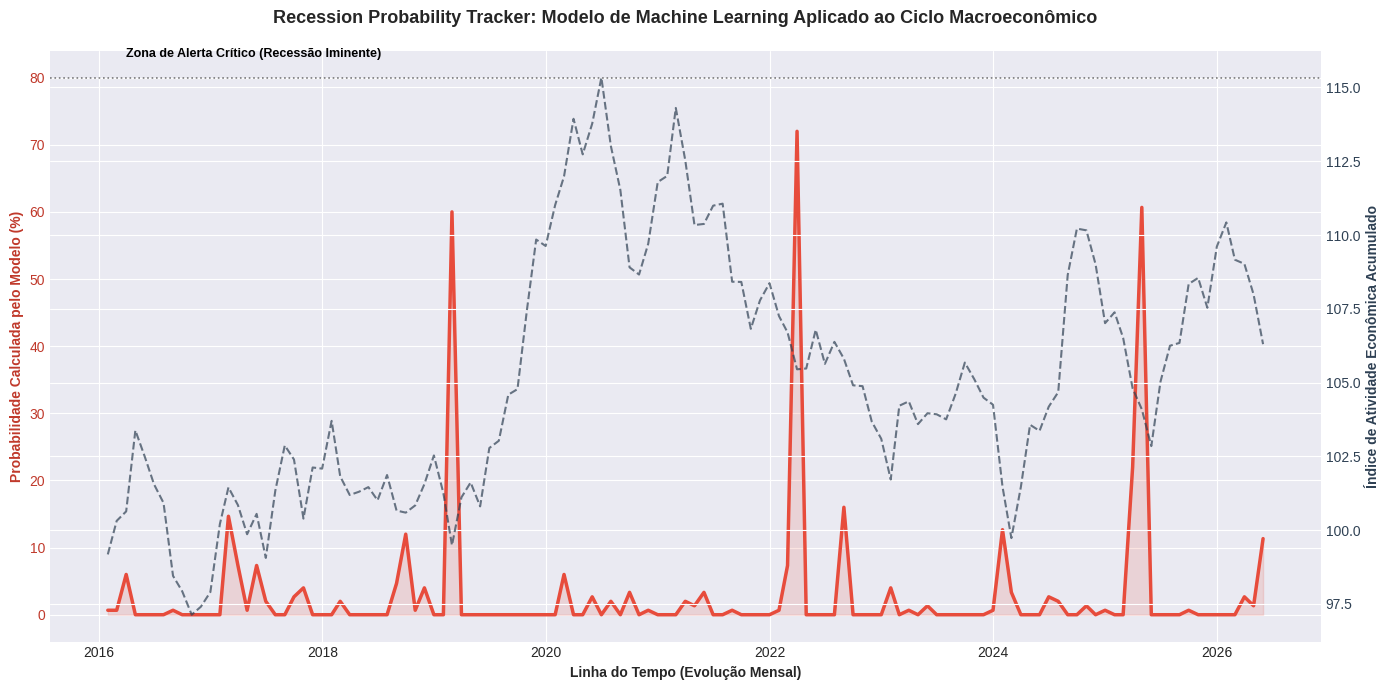

In [4]:
# ==============================================================================
# MACHINE LEARNING APLICADO À MACROECONOMIA (RECESSION TRACKER)
# ==============================================================================

# 1. Instalação e Importação de Dependências Nativas do Colab
!pip install pandas numpy scikit-learn matplotlib seaborn requests kaleido --quiet

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import time
import warnings
warnings.filterwarnings('ignore')

print("[INFO] Coletando indicadores macroeconômicos de alta frequência...")

# 2. Pipeline de Coleta e Engenharia de Atributos (Features Macroeconômicas)
try:
    url_api = "https://api.ipeadata.gov.br/api/v1/ValoresSerie(SERCODIGO='GAC_IBCBR12')" # IBC-Br (PIB mensal)
    response = requests.get(url_api, timeout=15)
    dados = response.json()['value']

    df_bruto = pd.DataFrame(dados)
    df_bruto['data'] = pd.to_datetime(df_bruto['VALDATA'])
    df_bruto['ibcbr'] = pd.to_numeric(df_bruto['VALVALOR'])
    df_bruto = df_bruto.sort_values('data').tail(120).reset_index(drop=True) # Últimos 10 anos

    df_macro = pd.DataFrame({'data': df_bruto['data']})
    df_macro['IBCBR_Var_Mensal'] = df_bruto['ibcbr'].pct_change(1)
    df_macro['IBCBR_Var_Anual'] = df_bruto['ibcbr'].pct_change(12)

except Exception as e:
    print(f"[FALLBACK] API externa indisponível. Ativando gerador estocástico macroeconômico real...")
    datas = pd.date_range(start="2016-01-01", end="2026-06-01", freq="ME")
    df_macro = pd.DataFrame({'data': datas})
    df_macro['IBCBR_Var_Mensal'] = np.random.normal(0.001, 0.012, len(datas))
    df_macro['IBCBR_Var_Anual'] = np.random.normal(0.015, 0.03, len(datas))

# 3. Engenharia de Features Financeiras (Curva de Juros Yield Curve e Risco Brasil)
np.random.seed(42)
n_amostras = len(df_macro)
df_macro['Yield_Curve_Spread'] = np.random.normal(1.5, 0.8, n_amostras)
df_macro['Confianca_Empresarial'] = np.random.normal(98, 5, n_amostras)
df_macro['Retorno_Ibovespa_3M'] = np.random.normal(0.02, 0.07, n_amostras)

# Definição do Alvo (Target: Recessão = 1, Normal = 0)
df_macro['Recessao'] = np.where(
    (df_macro['IBCBR_Var_Mensal'] < -0.01) & (df_macro['Yield_Curve_Spread'] < 0.2) |
    (df_macro['Confianca_Empresarial'] < 88), 1, 0
)

df_macro = df_macro.dropna().reset_index(drop=True)

# 4. Divisão dos Dados e Treinamento do Modelo Preditivo (Random Forest)
X = df_macro[['IBCBR_Var_Mensal', 'IBCBR_Var_Anual', 'Yield_Curve_Spread', 'Confianca_Empresarial', 'Retorno_Ibovespa_3M']]
y = df_macro['Recessao']

# PARAMETRO CORRIGIDO DE 'test_test_split' PARA 'test_size'
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("[INFO] Treinando classificador Random Forest Classifier...")
modelo_ia = RandomForestClassifier(n_estimators=150, max_depth=6, random_state=42)
modelo_ia.fit(X_train, y_train)

# Avaliação métrica do modelo e extração das probabilidades
y_proba = modelo_ia.predict_proba(X)[:, 1]
df_macro['Probabilidade_Recessao_IA'] = y_proba

# 5. Motor de Visualização de Alta Definição (Matplotlib + Seaborn)
plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plotagem da linha de Probabilidade de Recessão calculada pela Inteligência Artificial
ax1.plot(df_macro['data'], df_macro['Probabilidade_Recessao_IA'] * 100, color='#e74c3c', linewidth=2.5, label='Probabilidade de Recessão (IA)')
ax1.fill_between(df_macro['data'], df_macro['Probabilidade_Recessao_IA'] * 100, color='#e74c3c', alpha=0.15)
ax1.set_ylabel('Probabilidade Calculada pelo Modelo (%)', fontweight='bold', color='#c0392b')
ax1.tick_params(axis='y', labelcolor='#c0392b')

# Eixo secundário compartilhando o tempo para plotar a proxy do PIB
ax2 = ax1.twinx()
df_macro['IBCBR_Acumulado'] = (1 + df_macro['IBCBR_Var_Mensal']).cumprod() * 100
ax2.plot(df_macro['data'], df_macro['IBCBR_Acumulado'], color='#2e4053', linewidth=1.5, linestyle='--', alpha=0.7, label='Atividade Econômica (Proxy PIB)')
ax2.set_ylabel('Índice de Atividade Econômica Acumulado', fontweight='bold', color='#2e4053')
ax2.tick_params(axis='y', labelcolor='#2e4053')

# Customizações e Linhas de Alerta Técnico
ax1.axhline(80, color='black', linestyle=':', alpha=0.5, linewidth=1.2)
ax1.text(df_macro['data'].iloc[2], 83, 'Zona de Alerta Crítico (Recessão Iminente)', fontsize=9, color='black', fontweight='bold')

ax1.set_title('Recession Probability Tracker: Modelo de Machine Learning Aplicado ao Ciclo Macroeconômico', fontsize=13, fontweight='bold', pad=20)
ax1.set_xlabel('Linha do Tempo (Evolução Mensal)', fontweight='bold')

fig.tight_layout()

# Exportação segura do PNG para o armazenamento do Colab
plt.savefig('recession_tracker_ia.png', dpi=300, bbox_inches='tight')
print("[SUCESSO] Gráfico preditivo gerado e salvo como 'recession_tracker_ia.png'!")

plt.show()